# Notebook 03 — Factorization Machine (Baseline)

**Fields used:** `user_id`, `movie_id`, plus 19 binary genre fields  
**Split:** time-aware (last 20% of interactions by timestamp → test)  
**Output:** `models/fm_model.pt`, `models/fm_config.json`, `models/item_embeddings.npy`

In [21]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from src.fm_model import FactorizationMachine
from src.data_utils import build_id_mappings, train_test_split_by_time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Load Data

In [22]:
DATA_DIR = Path('../data/raw')

ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')

print(f'Ratings : {len(ratings):,} rows | {ratings.userId.nunique()} users | {ratings.movieId.nunique()} movies')
print(f'Rating range : {ratings.rating.min()} – {ratings.rating.max()}')
print(f'Movies  : {len(movies):,} rows | {movies.genres.str.split("|").explode().nunique()} unique genres')
ratings.head()

Ratings : 100,836 rows | 610 users | 9724 movies
Rating range : 0.5 – 5.0
Movies  : 9,742 rows | 20 unique genres


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Genre Encoding (20 binary fields)

In [23]:
ALL_GENRES = sorted(
    g for g in movies.genres.str.split('|').explode().unique()
    if g != '(no genres listed)'
)
print(f'{len(ALL_GENRES)} genres:', ALL_GENRES)

# binary one-hot per genre column on movies
for g in ALL_GENRES:
    movies[g] = movies.genres.str.contains(g, regex=False).astype(int)

# merge genre flags into ratings
ratings = ratings.merge(movies[['movieId'] + ALL_GENRES], on='movieId', how='left')
print('ratings shape after merge:', ratings.shape)
ratings.head(2)

19 genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
ratings shape after merge: (100836, 23)


,userId,movieId,rating,timestamp,Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,964982703,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,964981247,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


## 3. ID Mappings + Train/Test Split

In [24]:
user_mapping  = build_id_mappings(ratings, 'userId')
item_mapping  = build_id_mappings(ratings, 'movieId')

n_users = len(user_mapping)
n_items = len(item_mapping)
# each genre field is binary → cardinality 2
field_dims = [n_users, n_items] + [2] * len(ALL_GENRES)

print(f'n_users={n_users}, n_items={n_items}, n_genre_fields={len(ALL_GENRES)}')
print(f'field_dims ({len(field_dims)} fields):', field_dims[:5], '...')

train_df, test_df = train_test_split_by_time(ratings)
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

n_users=610, n_items=9724, n_genre_fields=19
field_dims (21 fields): [610, 9724, 2, 2, 2] ...
Train: 80,668 | Test: 20,168


## 4. PyTorch Dataset

In [25]:
class MovieLensDataset(Dataset):
    def __init__(self, df, user_mapping, item_mapping, genre_cols):
        self.users   = df['userId'].map(user_mapping).values
        self.items   = df['movieId'].map(item_mapping).values
        self.genres  = df[genre_cols].values.astype(np.int64)  # (N, n_genres)
        self.ratings = df['rating'].values.astype(np.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        x = np.concatenate([[self.users[idx], self.items[idx]], self.genres[idx]])
        return torch.tensor(x, dtype=torch.long), torch.tensor(self.ratings[idx])

BATCH = 512
train_ds = MovieLensDataset(train_df, user_mapping, item_mapping, ALL_GENRES)
test_ds  = MovieLensDataset(test_df,  user_mapping, item_mapping, ALL_GENRES)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 158 | Test batches: 40


## 5. Train FM

In [26]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            total_loss += criterion(pred, y).item() * len(y)
            total_n += len(y)
    return (total_loss / total_n) ** 0.5  # RMSE


def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3, device=DEVICE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_rmse': [], 'test_rmse': []}
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
            total_n += len(y)
        scheduler.step()
        train_rmse = (total_loss / total_n) ** 0.5
        test_rmse  = evaluate(model, test_loader, criterion, device)
        history['train_rmse'].append(train_rmse)
        history['test_rmse'].append(test_rmse)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:02d}/{epochs} | train RMSE {train_rmse:.4f} | test RMSE {test_rmse:.4f}')
    return model, history


fm_model = FactorizationMachine(field_dims=field_dims, embed_dim=16)
print('Parameters:', sum(p.numel() for p in fm_model.parameters()))
fm_model, fm_history = train_model(fm_model, train_loader, test_loader, epochs=20)

Parameters: 176325
Epoch 01/20 | train RMSE 1.4208 | test RMSE 1.0258
Epoch 05/20 | train RMSE 0.8218 | test RMSE 1.0145
Epoch 10/20 | train RMSE 0.8054 | test RMSE 1.0145
Epoch 15/20 | train RMSE 0.7982 | test RMSE 1.0180
Epoch 20/20 | train RMSE 0.7948 | test RMSE 1.0177


## 6. Loss Curves

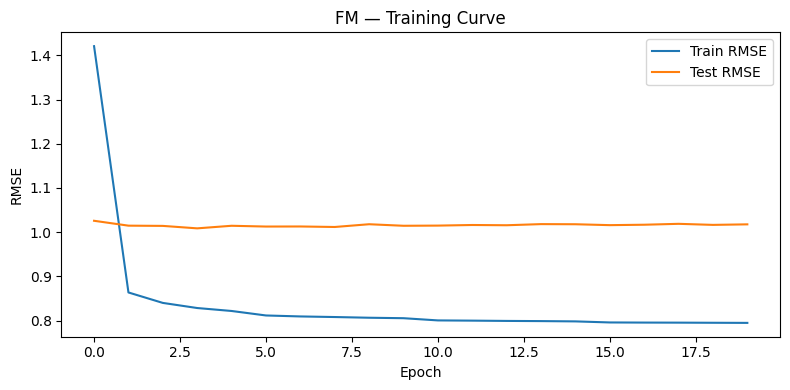

Best test RMSE: 1.0087


In [27]:
plt.figure(figsize=(8, 4))
plt.plot(fm_history['train_rmse'], label='Train RMSE')
plt.plot(fm_history['test_rmse'],  label='Test RMSE')
plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.title('FM — Training Curve')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Best test RMSE: {min(fm_history["test_rmse"]):.4f}')

## 7. Save Artifacts

In [28]:
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# model weights
torch.save(fm_model.state_dict(), MODELS_DIR / 'fm_model.pt')

# config — single source of truth for backend inference
fm_config = {
    'model_type' : 'fm',
    'field_dims' : field_dims,
    'embed_dim'  : 16,
    'genre_cols' : ALL_GENRES,
    'user_mapping': {str(k): v for k, v in user_mapping.items()},
    'item_mapping': {str(k): v for k, v in item_mapping.items()},
}
with open(MODELS_DIR / 'fm_config.json', 'w') as f:
    json.dump(fm_config, f, indent=2)

# item embeddings (from FM embedding table) — used by similarity module
item_embeddings = fm_model.get_item_embeddings(
    item_field_index=1,
    item_offset_within_field=range(n_items)
).numpy()
np.save(MODELS_DIR / 'item_embeddings.npy', item_embeddings)

print('Saved:')
print(f'  fm_model.pt          ({Path(MODELS_DIR/"fm_model.pt").stat().st_size/1024:.1f} KB)')
print(f'  fm_config.json')
print(f'  item_embeddings.npy  shape={item_embeddings.shape}')

Saved:
  fm_model.pt          (690.9 KB)
  fm_config.json
  item_embeddings.npy  shape=(9724, 16)


## 8. Sanity Check — sample predictions

In [29]:
fm_model.eval()
sample = test_df.head(10).copy()
ds_sample = MovieLensDataset(sample, user_mapping, item_mapping, ALL_GENRES)
xs = torch.stack([ds_sample[i][0] for i in range(len(ds_sample))])
with torch.no_grad():
    preds = fm_model(xs.to(DEVICE)).cpu().numpy()
preds_clipped = np.clip(preds, 0.5, 5.0)
sample['predicted'] = preds_clipped
sample[['userId','movieId','rating','predicted']]

,userId,movieId,rating,predicted
80668,495,72998,5.0,4.251744
80669,495,2762,4.5,4.474226
80670,495,4993,0.5,4.732041
80671,495,89492,5.0,4.329234
80672,495,2028,4.5,4.653642
80673,495,5952,0.5,4.668234
80674,495,1193,5.0,4.766450
80675,495,4995,5.0,4.661280
80676,495,48516,5.0,4.826151
80677,495,1259,4.5,4.543161
